In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor  # Changed to Regressor for predicting views
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import seaborn as sns


In [2]:
# TESTING ON 100 rows
df = pd.read_csv('ml_final_project_data/cleaned_data.csv')
df.head()

# Features and label
X = df.drop(columns=['views', 'region'])
y = df['views']

X.head()


,platform,country,category,sound_type,duration_sec,likes,comments,trend_label,genre,publish_dayofweek,publish_period,creator_avg_views,title_length,completion_rate,traffic_source
0,1,Us,Food,licensed,26,1868,257,rising,Travel,Sunday,Evening,86079.6,22,0.777,ForYou
1,1,Us,Fitness,trending,18,8917,1084,seasonal,Music,Sunday,Night,101492.8,17,0.728,ForYou
2,1,Us,Comedy,trending,62,35108,4168,rising,Pets,Friday,Evening,91145.8,20,0.806,ForYou
3,1,Mx,Travel,trending,23,3677,307,declining,Lifestyle,Thursday,Afternoon,85917.1,24,0.678,ForYou
4,1,Mx,Lifestyle,original,41,1373,151,declining,Beauty,Saturday,Night,90734.5,22,0.815,ForYou


In [3]:
# Check data types to identify categorical columns
print("Data types:")
print(df.dtypes)
print("\n" + "="*50)
print("Categorical columns (object type):")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)
print(f"\nTotal categorical columns: {len(categorical_cols)}")

Data types:
platform               int64
country               object
region                object
category              object
sound_type            object
duration_sec           int64
views                  int64
likes                  int64
comments               int64
trend_label           object
genre                 object
publish_dayofweek     object
publish_period        object
creator_avg_views    float64
title_length           int64
completion_rate      float64
traffic_source        object
dtype: object

Categorical columns (object type):
['country', 'region', 'category', 'sound_type', 'trend_label', 'genre', 'publish_dayofweek', 'publish_period', 'traffic_source']

Total categorical columns: 9


Encoded 'country': 3 unique categories
Encoded 'region': 1 unique categories
Encoded 'category': 19 unique categories
Encoded 'sound_type': 3 unique categories
Encoded 'trend_label': 4 unique categories
Encoded 'genre': 14 unique categories
Encoded 'publish_dayofweek': 7 unique categories
Encoded 'publish_period': 4 unique categories
Encoded 'traffic_source': 6 unique categories

Total columns encoded: 9
All categorical data converted to numeric!
Added feature 'duration_title_ratio'. Sample values:
   duration_sec  title_length  duration_title_ratio
0            26            22              1.181818
1            18            17              1.058824
2            62            20              3.100000
3            23            24              0.958333
4            41            22              1.863636

Features shape: (4864, 16)
Target shape: (4864,)

All data is now numeric: True
Total rows: 4864


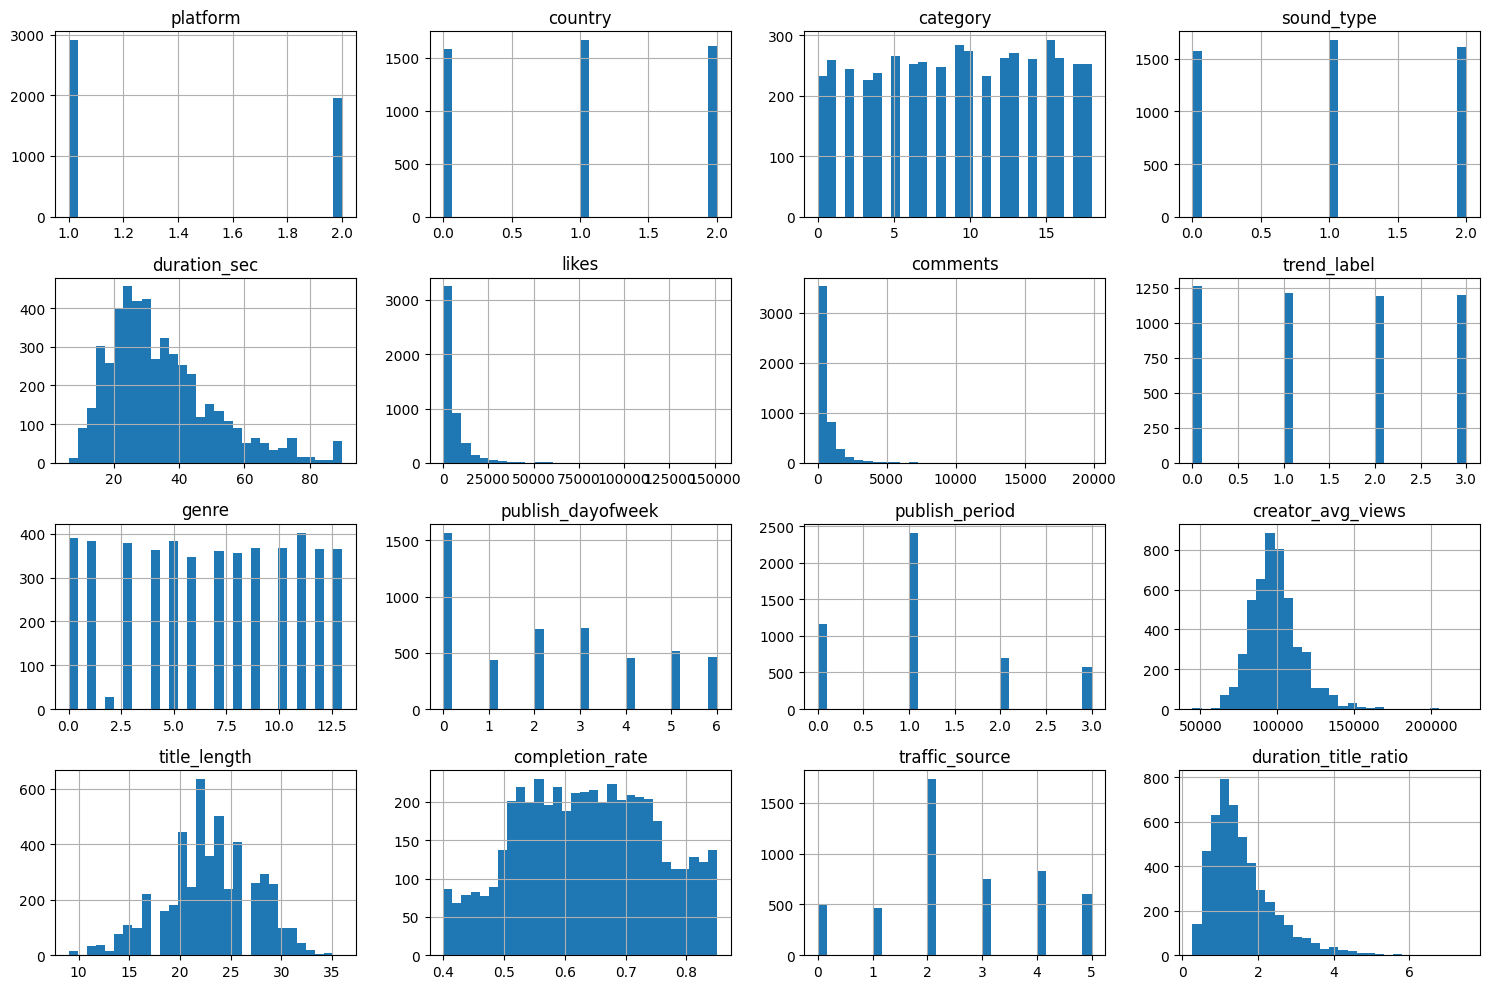

In [4]:
# Convert categorical columns to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying original
df_encoded = df.copy()

# Get categorical columns (excluding 'views' which is our target)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()

# Remove 'views' if it's in the list (it's our target)
if 'views' in categorical_cols:
    categorical_cols.remove('views')

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': {len(le.classes_)} unique categories")

print("\n" + "="*50)
print(f"Total columns encoded: {len(categorical_cols)}")
print("All categorical data converted to numeric!")

# Add duration-to-title-length ratio feature (safe to divide)
# Assumes df_encoded already exists and has numeric 'duration_sec' and 'title_length'

#prevent divisions by zero
df_encoded['duration_title_ratio'] = (
    df_encoded['duration_sec'] / df_encoded['title_length'].replace({0: np.nan})
).fillna(0)

print("Added feature 'duration_title_ratio'. Sample values:")
print(df_encoded[['duration_sec', 'title_length', 'duration_title_ratio']].head())

# Update X and y with encoded data
X_encoded = df_encoded.drop(columns=['views', 'region'])
y_encoded = df_encoded['views']

print("\n" + "="*50)
print(f"Features shape: {X_encoded.shape}")
print(f"Target shape: {y_encoded.shape}")
print(f"\nAll data is now numeric: {X_encoded.select_dtypes(include=['object']).shape[1] == 0}")
print("Total rows:", X_encoded.shape[0])

X_encoded.head()

#Plotting Histiogram of each feature to geta feel of the data distribution.
import matplotlib.pyplot as plt
#exluding views and region from histogram
df_encoded.drop(columns=['views', 'region']).hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

FEATURE CORRELATION WITH TARGET (Views)
likes                   0.883089
comments                0.858574
creator_avg_views       0.107315
category                0.032369
sound_type              0.010213
title_length            0.005943
publish_period          0.004697
duration_sec            0.000400
traffic_source         -0.000465
duration_title_ratio   -0.002298
publish_dayofweek      -0.003635
completion_rate        -0.006328
platform               -0.007127
genre                  -0.008566
country                -0.008583
trend_label            -0.026801
Name: views, dtype: float64


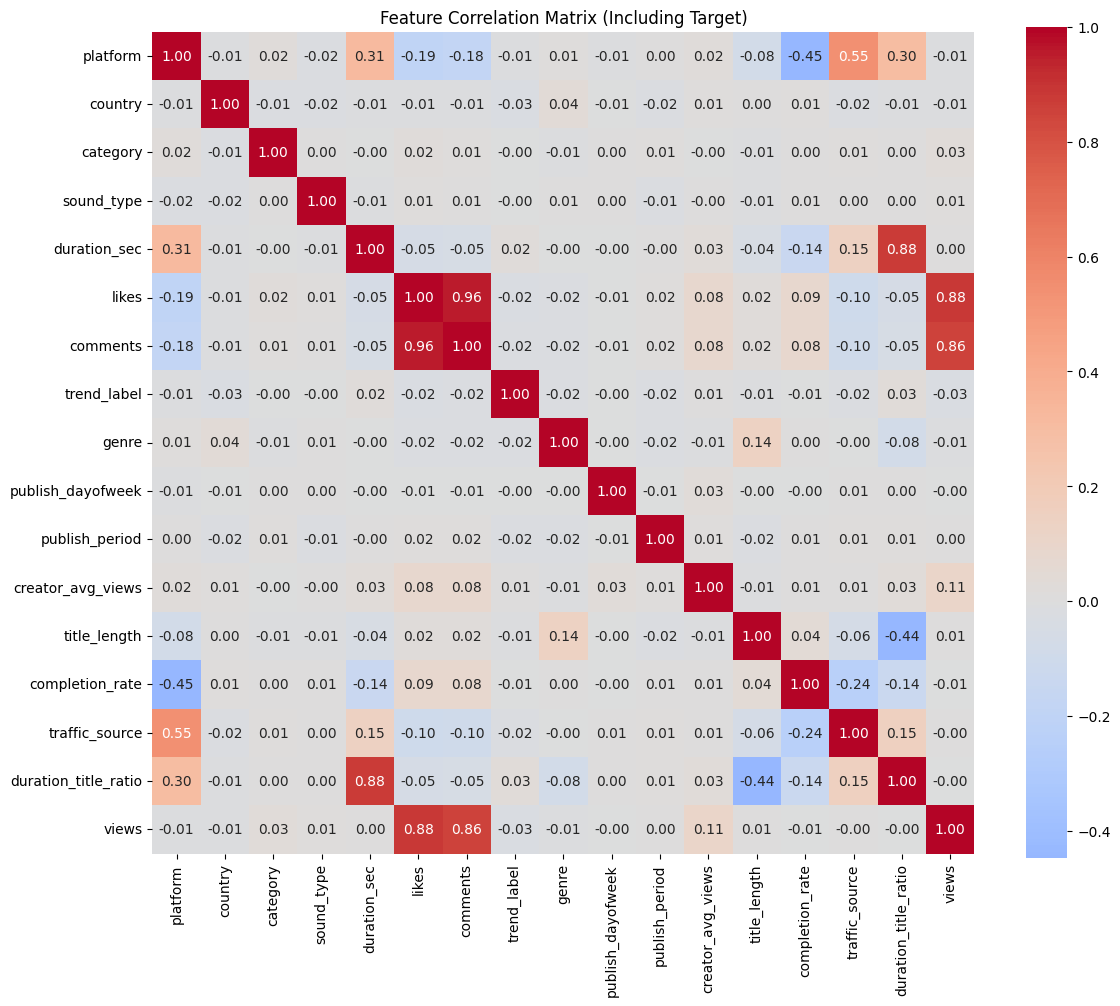

In [5]:
#Computing Feature Correlations
#Need seaborn as sns

# Compute correlation matrix
correlation_matrix = X_encoded.copy()
correlation_matrix['views'] = y_encoded
correlation_with_target = correlation_matrix.corr()['views'].drop('views').sort_values(ascending=False)

print("="*70)
print("FEATURE CORRELATION WITH TARGET (Views)")
print("="*70)
print(correlation_with_target)
print("="*70)

# Heatmap of all correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title("Feature Correlation Matrix (Including Target)")
plt.tight_layout()
plt.show()


In [6]:
# Hyperparameter grid for XGBoost Regressor
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

print("Parameter grid:", param_grid)
print(f"Total combinations: {2 * 2 * 1 * 1 * 1} = 4")

Parameter grid: {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.1], 'subsample': [0.8], 'colsample_bytree': [0.8]}
Total combinations: 4 = 4


In [7]:
# Train XGBoost Regressor with GridSearchCV on all rows
print("Training XGBoost Regressor with GridSearchCV...")

# Use negative MSE as scoring (GridSearchCV maximizes, so negative)
model = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1
)

model.fit(X_encoded, y_encoded)

# Get best parameters and model
best_params = model.best_params_
best_model = model.best_estimator_

# Make predictions
y_pred = best_model.predict(X_encoded)

# Calculate metrics
mse = mean_squared_error(y_encoded, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_encoded, y_pred)
r2 = r2_score(y_encoded, y_pred)

print("\n" + "="*50)
print("XGBoost Regressor Results")
print("="*50)
print("Best Parameters:", best_params)
print(f"RMSE: {rmse:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"R² Score: {r2:.4f}")
print("="*50)

Training XGBoost Regressor with GridSearchCV...

XGBoost Regressor Results
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
RMSE: 40,023.97
MAE: 22,100.64
R² Score: 0.9015


Top 10 Most Important Features:
                 feature  importance
5                  likes    0.343501
6               comments    0.245656
4           duration_sec    0.065762
0               platform    0.055893
14        traffic_source    0.043422
2               category    0.042418
15  duration_title_ratio    0.039266
10        publish_period    0.033549
1                country    0.033273
13       completion_rate    0.031465


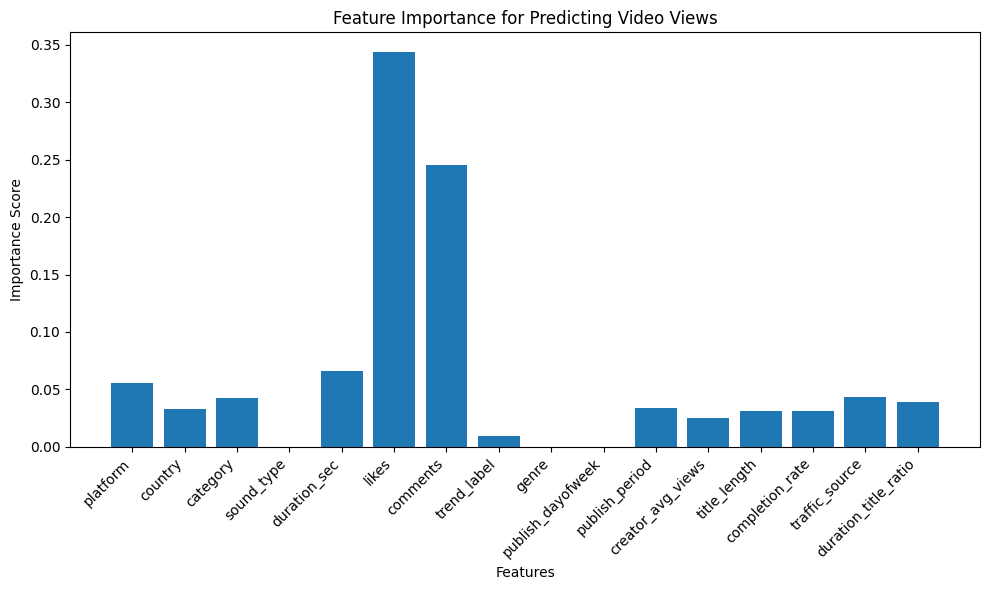

In [8]:
# Feature Importance
importances = best_model.feature_importances_
features = X_encoded.columns

# Create dataframe for easier analysis
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance_df.head(10))

plt.figure(figsize=(10,6))
plt.bar(features, importances)
plt.title("Feature Importance for Predicting Video Views")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Scale features for Linear Regression and K-Means
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Convert back to DataFrame to keep column names
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

# K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)



In [10]:
# K-Means Clustering with Scaled Features
from sklearn.cluster import KMeans
#Need pandas as pd and numpy as np imported already

# Fit KMeans on scaled features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_df)

# X_scaled_df, kmeans, kmeans_labels, scaler, y_encoded assumed defined above
cluster_series = pd.Series(kmeans_labels, name='cluster')
df_clusters = pd.concat([X_scaled_df.reset_index(drop=True), cluster_series.reset_index(drop=True), y_encoded.reset_index(drop=True)], axis=1)

# Cluster counts and view stats
cluster_counts = df_clusters['cluster'].value_counts().sort_index()
cluster_view_stats = df_clusters.groupby('cluster')['views'].agg(['count','mean','median','std']).rename(columns={'count':'n'})

print("Cluster counts:\n", cluster_counts)
print("\nCluster view stats (# of videos in cluster, mean views, median views, std views):\n", cluster_view_stats)

# Quick note: Can't use clusters as later feature because we use cross-validation which would leak info
# Next we give train/test split to avoid leakage

Cluster counts:
 cluster
0     962
1     814
2     975
3     990
4    1123
Name: count, dtype: int64

Cluster view stats (# of videos in cluster, mean views, median views, std views):
             n           mean   median            std
cluster                                             
0         962   93280.234927  56351.5  116291.977774
1         814  100200.658477  62176.5  120476.247686
2         975   94872.769231  57698.0  124793.827204
3         990  101278.639394  59731.5  139310.129669
4        1123  102208.209261  63094.0  133100.697147


In [11]:
# Linear Regression with CLUSTER Features compare to model without cluster features
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

#To avoid cross validation problem, using train/test split

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y_encoded, test_size=0.2, random_state=42
)
#retrain KMeans on training data only
kmeans_train = KMeans(n_clusters=5, random_state=42, n_init=10)
train_clusters = kmeans_train.fit_predict(X_train)
test_clusters = kmeans_train.predict(X_test)

X_train_with_clusters = X_train.copy()
X_train_with_clusters['kmeans_cluster'] = train_clusters

X_test_with_clusters = X_test.copy()
X_test_with_clusters['kmeans_cluster'] = test_clusters

lr_model_cluster = LinearRegression()
lr_model_cluster.fit(X_train_with_clusters, y_train)
y_pred_cluster = lr_model_cluster.predict(X_test_with_clusters)
rmse_cluster = np.sqrt(mean_squared_error(y_test, y_pred_cluster))
mae_cluster = mean_absolute_error(y_test, y_pred_cluster)
r2_cluster = r2_score(y_test, y_pred_cluster)

print(f"Linear Regression (with clusters):")
print("="*50)
print(f"  Test RMSE: {rmse_cluster:,.2f}")
print(f"  Test MAE: {mae_cluster:,.2f}")
print(f"  Test R²: {r2_cluster:.4f}")
print("="*50)

Linear Regression (with clusters):
  Test RMSE: 52,125.13
  Test MAE: 29,460.28
  Test R²: 0.8560


In [12]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression

print("Training Linear Regression Model (with scaled features)...")

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_scaled_df, y_encoded)

# Make predictions
y_pred_lr = lr_model.predict(X_scaled_df)

# Perform cross-validation predictions
y_pred_lr_cv = cross_val_predict(lr_model, X_scaled_df, y_encoded, cv=kf)

# Calculate metrics
mse_lr = mean_squared_error(y_encoded, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_encoded, y_pred_lr)
r2_lr = r2_score(y_encoded, y_pred_lr)

# Calculate cross-validation metrics
mse_lr_cv = mean_squared_error(y_encoded, y_pred_lr_cv)
rmse_lr_cv = np.sqrt(mse_lr_cv)
mae_lr_cv = mean_absolute_error(y_encoded, y_pred_lr_cv)
r2_lr_cv = r2_score(y_encoded, y_pred_lr_cv)


print("\n" + "="*50)
print("Linear Regression Results (Scaled Features)")
print("="*50)
print(f"RMSE: {rmse_lr:,.2f}")
print(f"MAE: {mae_lr:,.2f}")
print(f"R² Score: {r2_lr:.4f}")
print("="*50)
print("Cross-Validation Results:")
print(f"CV RMSE: {rmse_lr_cv:,.2f}")
print(f"CV MAE: {mae_lr_cv:,.2f}")
print(f"CV R² Score: {r2_lr_cv:.4f}")
print("="*50)


Training Linear Regression Model (with scaled features)...

Linear Regression Results (Scaled Features)
RMSE: 55,460.23
MAE: 28,640.67
R² Score: 0.8109
Cross-Validation Results:
CV RMSE: 57,269.78
CV MAE: 29,004.08
CV R² Score: 0.7983


In [13]:
# Polynomial Regression Model 
from sklearn.preprocessing import PolynomialFeatures


p_features = PolynomialFeatures(degree=2)
X_poly = p_features.fit_transform(X_scaled_df)

# Train-test split
kf = KFold(n_splits=5, random_state=42, shuffle=True)

# Train polynomial regression model
p_model = LinearRegression()
p_model.fit(X_poly, y_encoded)

y_pred_p = p_model.predict(X_poly)

# Perform cross-validation predictions
y_pred_p_cv = cross_val_predict(p_model, X_poly, y_encoded, cv=kf)

# Calculate metrics
mse_p = mean_squared_error(y_encoded, y_pred_p)
rmse_p = np.sqrt(mse_p)
mae_p = mean_absolute_error(y_encoded, y_pred_p)
r2_p = r2_score(y_encoded, y_pred_p)
# Calculate cross-validation metrics
mse_p_cv = mean_squared_error(y_encoded, y_pred_p_cv)
rmse_p_cv = np.sqrt(mse_p_cv)
mae_p_cv = mean_absolute_error(y_encoded, y_pred_p_cv)
r2_p_cv = r2_score(y_encoded, y_pred_p_cv)
print("\n" + "="*50)
print("Polynomial Regression Results (Scaled Features)")
print("="*50)
print(f"RMSE: {rmse_p:,.2f}")
print(f"MAE: {mae_p:,.2f}")
print(f"R² Score: {r2_p:.4f}")
print("="*50)
print("Cross-Validation Results:")
print(f"CV RMSE: {rmse_p_cv:,.2f}")
print(f"CV MAE: {mae_p_cv:,.2f}")
print(f"CV R² Score: {r2_p_cv:.4f}")
print("="*50)






Polynomial Regression Results (Scaled Features)
RMSE: 42,191.75
MAE: 23,387.64
R² Score: 0.8905
Cross-Validation Results:
CV RMSE: 48,867.98
CV MAE: 25,326.25
CV R² Score: 0.8532


/var/folders/v_/dnz1m23s5279wvx8lyy4mp_w0000gn/T/ipykernel_67345/174172885.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


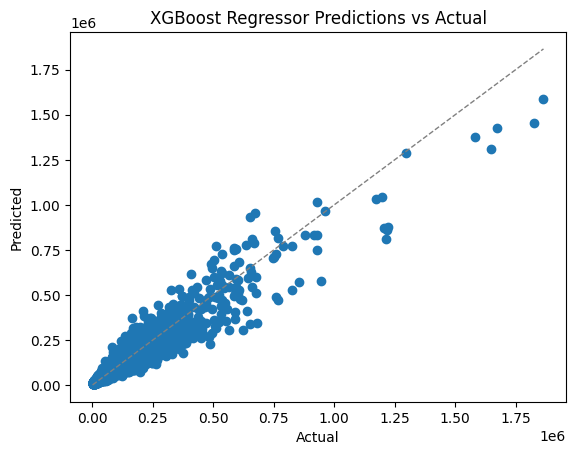

/var/folders/v_/dnz1m23s5279wvx8lyy4mp_w0000gn/T/ipykernel_67345/174172885.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


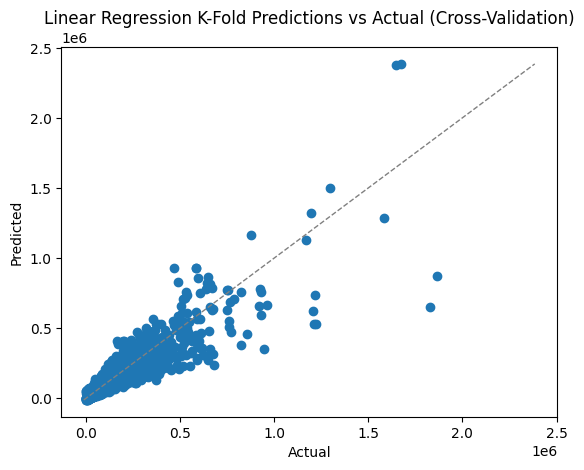

/var/folders/v_/dnz1m23s5279wvx8lyy4mp_w0000gn/T/ipykernel_67345/174172885.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(lims, lims, 'k--', color='grey', linewidth=1)


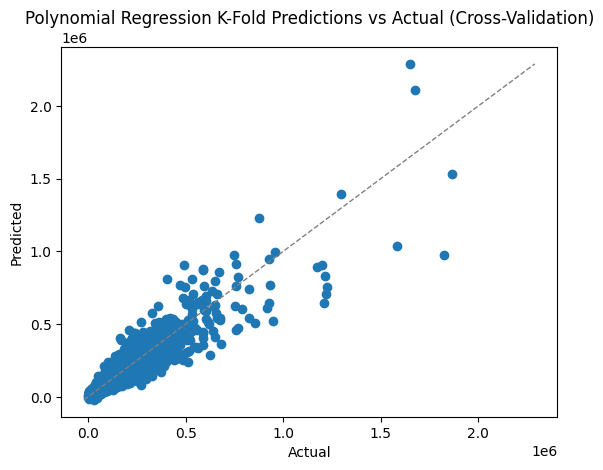

In [14]:
# Visualizing Models

# XGBoost Predictions vs Actual
plt.scatter(y_encoded, y_pred)
plt.title(f'XGBoost Regressor Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
lims = [
    np.min([y_encoded.min(), y_pred.min()]),
    np.max([y_encoded.max(), y_pred.max()])
]
# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)
plt.show()

# Linear Regression Predictions vs Actual
# K-fold cross-validation visualization
plt.scatter(y_encoded, y_pred_lr_cv)
plt.title(f'Linear Regression K-Fold Predictions vs Actual (Cross-Validation)')
plt.xlabel('Actual')
plt.ylabel('Predicted')

lims = [
    np.min([y_encoded.min(), y_pred_lr_cv.min()]),
    np.max([y_encoded.max(), y_pred_lr_cv.max()])
]

# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)  

plt.show()

# Polynomial Regression Predictions vs Actual
plt.scatter(y_encoded, y_pred_p_cv)
plt.title(f'Polynomial Regression K-Fold Predictions vs Actual (Cross-Validation)')
plt.xlabel('Actual')
plt.ylabel('Predicted')
lims = [
    np.min([y_encoded.min(), y_pred_p_cv.min()]),
    np.max([y_encoded.max(), y_pred_p_cv.max()])
]
# Add diagonal line
plt.plot(lims, lims, 'k--', color='grey', linewidth=1)
plt.show()


Top 10 Most Important Features (Linear Regression)
                 feature   coefficient
5                  likes  1.868766e+06
6               comments  4.024826e+05
0               platform  4.232068e+04
11     creator_avg_views  4.104757e+04
13       completion_rate  6.579652e+03
2               category  6.194510e+03
15  duration_title_ratio  5.491009e+03
10        publish_period  4.470231e+03
8                  genre  2.962995e+03
14        traffic_source  1.360260e+03


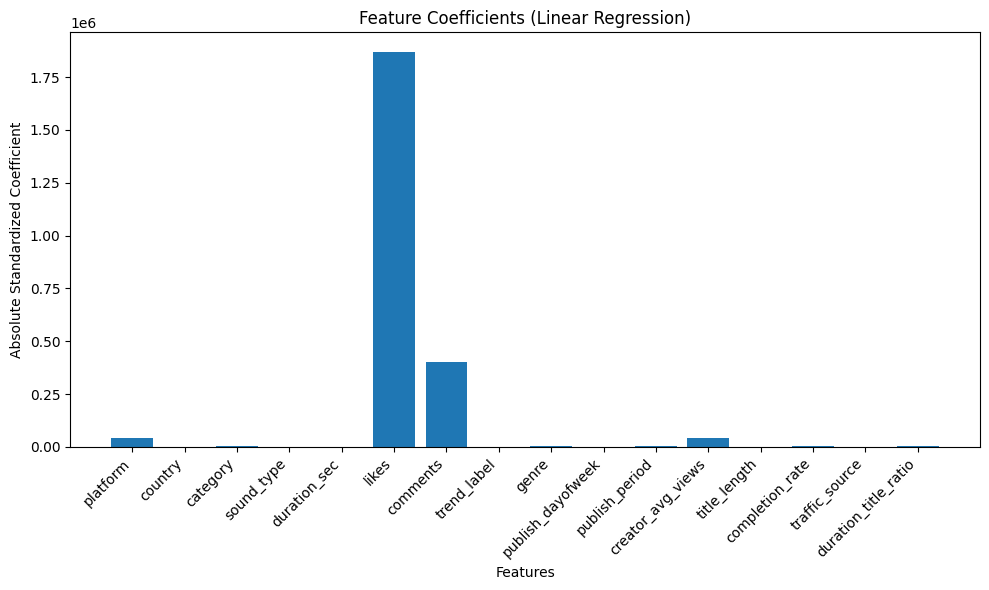

In [15]:
# Feature Importance for Linear Regression (Coefficients)

coefficients = lr_model.coef_
features_lr = X_scaled_df.columns

# Create dataframe for easier analysis
coef_importance_df = pd.DataFrame({
    'feature': features_lr,
    'coefficient': np.abs(coefficients)  # Use absolute values
}).sort_values('coefficient', ascending=False)

print("Top 10 Most Important Features (Linear Regression)")
print(coef_importance_df.head(10))

plt.figure(figsize=(10,6))
plt.bar(features_lr, np.abs(coefficients))
plt.title("Feature Coefficients (Linear Regression)")
plt.xlabel("Features")
plt.ylabel("Absolute Standardized Coefficient")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Neural Network Data Preparation 
from sklearn.neural_network import MLPRegressor


X_nn = df_encoded.drop(columns=['views', 'region'])
y_nn = df_encoded['views']

# Train/test split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=42
)

# Scaling (Neural Nets NEED scaling)
scaler_nn = StandardScaler()
X_train_nn_scaled = scaler_nn.fit_transform(X_train_nn)
X_test_nn_scaled  = scaler_nn.transform(X_test_nn)

# Neural Network Model
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1
)

nn_model.fit(X_train_nn_scaled, y_train_nn)

# Neural network evaluation
y_pred_nn = nn_model.predict(X_test_nn_scaled)

nn_mae = mean_absolute_error(y_test_nn, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test_nn, y_pred_nn))
nn_r2 = r2_score(y_test_nn, y_pred_nn)

print("Neural Net Regression Performance:")
print(f"MAE  : {nn_mae:,.2f}")
print(f"RMSE : {nn_rmse:,.2f}")
print(f"R²   : {nn_r2:.4f}")

Neural Net Regression Performance:
MAE  : 42,922.28
RMSE : 69,572.62
R²   : 0.7434


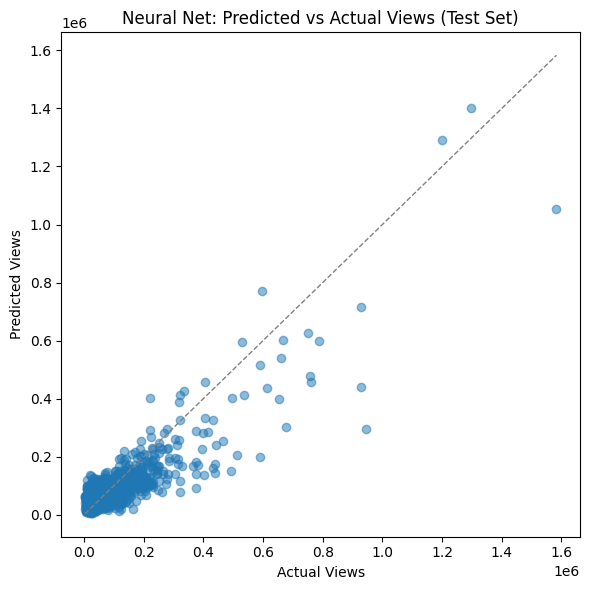

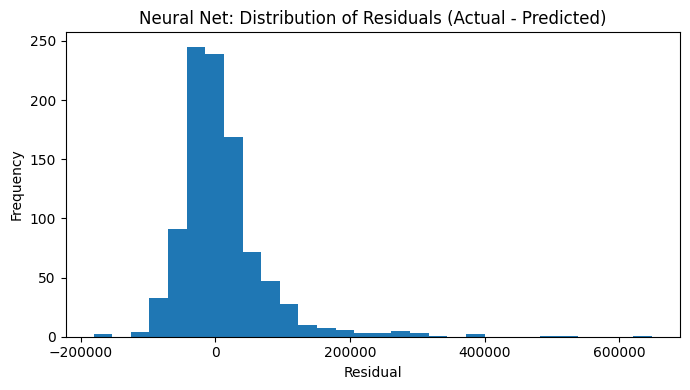

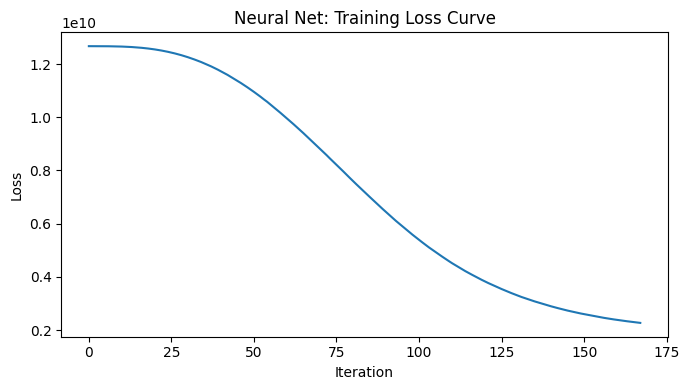

In [17]:
# Visualisations for Neural Network

import matplotlib.pyplot as plt
import numpy as np

# 1) Actual vs Predicted (Test Set)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_nn, y_pred_nn, alpha=0.5)
plt.title("Neural Net: Predicted vs Actual Views (Test Set)")
plt.xlabel("Actual Views")
plt.ylabel("Predicted Views")

# 45° reference line
lims = [
    np.min([y_test_nn.min(), y_pred_nn.min()]),
    np.max([y_test_nn.max(), y_pred_nn.max()])
]
plt.plot(lims, lims, linestyle="--", color="grey", linewidth=1)
plt.tight_layout()
plt.show()

# 2) Residuals Histogram
residuals_nn = y_test_nn - y_pred_nn

plt.figure(figsize=(7, 4))
plt.hist(residuals_nn, bins=30)
plt.title("Neural Net: Distribution of Residuals (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3) Loss Curve Over Training Iterations
plt.figure(figsize=(7, 4))
plt.plot(nn_model.loss_curve_)
plt.title("Neural Net: Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()


In [18]:
# Model Comparison
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'Linear Regression (Cross-Validation)', 'Polynomial Regression (Cross-Validation)'],
    'RMSE': [rmse, rmse_lr_cv, rmse_p_cv],
    'MAE': [mae, mae_lr_cv, mae_p_cv],
    'R² Score': [r2, r2_lr_cv, r2_p_cv]
})

print("\n" + "="*100)
print("MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)




MODEL COMPARISON
                                   Model         RMSE          MAE  R² Score
                                 XGBoost 40023.970418 22100.644531  0.901496
    Linear Regression (Cross-Validation) 57269.780331 29004.084665  0.798319
Polynomial Regression (Cross-Validation) 48867.983680 25326.246417  0.853154
